### Loading and Preprocessing MNIST

Load the MNIST training dataset using `torchvision.datasets`.  
Each 28×28 image is converted to a tensor, normalized to `[0,1]`, and flattened into a 784-length vector for model input.

In [27]:
import torch
from torch.utils.data import random_split
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))
])

full_dataset = datasets.MNIST(root="/content/temp_data", train=True, transform=transform, download=True)

### Creating a Binary Dataset for Logistic Regression Model (Digits 0 and 1)

Select only samples labeled **0** and **1** from the full MNIST dataset  
to create a smaller binary classification dataset, which will be used  
for training a logistic regression model.

In [28]:
from torch.utils.data import Subset

indices_01 = [i for i, (_, y) in enumerate(full_dataset) if y in (0, 1)]
binary_dataset = Subset(full_dataset, indices_01)

print(f"Full dataset size: {len(full_dataset)}")
print(f"Binary dataset (0 and 1) size: {len(binary_dataset)}")

Full dataset size: 60000
Binary dataset (0 and 1) size: 12665


### Visualizing Example Digits

Display one sample image for each digit (**0** and **1**)  
from the binary dataset to confirm that the data is loaded  
and labeled correctly.

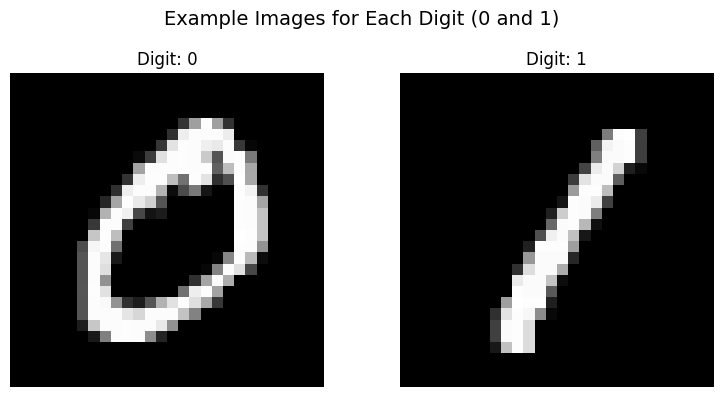

In [ ]:

# Store one example image for each digit
examples = {}
for img, label in binary_dataset:
    if label not in examples:
        examples[label] = img
    if len(examples) == 2:
        break

# Plotting
plt.figure(figsize=(8, 4))
for i in range(2):
    plt.subplot(1, 2, i + 1)
    plt.imshow(examples[i].view(28, 28), cmap='gray')  # reshape to 28*28 image
    plt.title(f"Digit: {i}")
    plt.axis('off')

plt.suptitle("Example Images for Each Digit (0 and 1)", fontsize=14)
plt.subplots_adjust(top=0.8)
plt.tight_layout()
plt.show()


### Visualizing Label Distribution

Plot a pie chart showing the percentage of each digit (**0** and **1**)  
in the binary dataset to verify that the data is balanced.

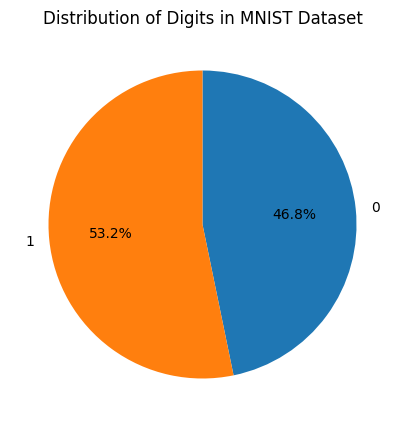

In [ ]:

# Get labels
labels = [label for _, label in binary_dataset]

# Count how many times each label appears
unique_labels, counts = torch.unique(torch.tensor(labels), return_counts=True)

# Plotting
plt.figure(figsize=(5, 5))
plt.pie(counts, labels=unique_labels.tolist(), autopct='%1.1f%%', startangle=90, counterclock=False)
plt.title("Distribution of Digits in MNIST Dataset")
plt.show()

### Splitting the Binary Dataset

Divide the binary dataset into train (60%), validation (20%), and test (20%) subsets.  
Also, display key details like dataset sizes, feature dimensions, and a sample example.

In [29]:

train_size = int(0.6 * len(binary_dataset))
val_size   = int(0.2 * len(binary_dataset))
test_size  = len(binary_dataset) - train_size - val_size

train_dataset_bin, val_dataset_bin, test_dataset_bin = torch.utils.data.random_split(
    binary_dataset, [train_size, val_size, test_size], generator=torch.Generator().manual_seed(42)
)

# Get one sample to inspect
x_sample, y_sample = binary_dataset[0]
feature_dim = x_sample.numel()

# Print dataset info
print("Binary Dataset Summary\n")
print(f"Total samples:        {len(binary_dataset)}")
print(f"Training samples:     {len(train_dataset_bin)}")
print(f"Validation samples:   {len(val_dataset_bin)}")
print(f"Test samples:         {len(test_dataset_bin)}")
print(f"Feature dimension:    {feature_dim}")
print(f"Sample tensor shape:  {tuple(x_sample.shape)}")
print(f"Example label:        {y_sample}")


Binary Dataset Summary

Total samples:        12665
Training samples:     7599
Validation samples:   2533
Test samples:         2533
Feature dimension:    784
Sample tensor shape:  (784,)
Example label:        0


### Creating DataLoaders

Wrap the train, validation, and test subsets into **DataLoaders** with a batch size of 64.  
This allows efficient mini-batch loading during model training and evaluation.

In [30]:

# Create DataLoaders for binary classification
train_loader_bin = DataLoader(train_dataset_bin, batch_size=64, shuffle=True)
val_loader_bin   = DataLoader(val_dataset_bin, batch_size=64, shuffle=False)
test_loader_bin  = DataLoader(test_dataset_bin, batch_size=64, shuffle=False)

print("DataLoaders created successfully\n")
print("Batch size: 64")
print(f"No. of rain batches: {len(train_loader_bin)}")
print(f"No. of validation batches: {len(val_loader_bin)}")
print(f"No. of test batches: {len(test_loader_bin)}")


DataLoaders created successfully

Batch size: 64
No. of rain batches: 119
No. of validation batches: 40
No. of test batches: 40


### Defining the Logistic Regression Model

Initialize model parameters `W` (weights) and `b` (bias), define the **sigmoid activation**,  
and implement the **binary cross-entropy loss** used for training a binary classifier.

In [31]:

W = torch.randn(28*28, 1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)

def sigmoid(z):
    return 1 / (1 + torch.exp(-z))

def model(X):
    return sigmoid(X @ W + b)

def binary_cross_entropy(y_pred, y_true):
    eps = 1e-8
    return -torch.mean(y_true * torch.log(y_pred+eps) + (1-y_true) * torch.log(1-y_pred+eps))


### Model Training Loop

Train the logistic regression model for **20 epochs** using **batch gradient descent**.  
For each epoch:
- Compute predictions and loss on the training set.  
- Update model parameters (`W` and `b`) using gradient descent.  
- Evaluate performance on the validation set (without gradient updates).  

Both **loss** and **accuracy** for training and validation are recorded for analysis.

In [32]:
learning_rate = 0.01
epochs = 20
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(epochs):
    total_train_loss, correct_train, total_train = 0, 0, 0

    for X_batch, y_batch in train_loader_bin:
        y_true = y_batch.float().view(-1, 1)
        y_pred = model(X_batch)
        loss = binary_cross_entropy(y_pred, y_true)

        # Gradient Descent
        loss.backward()
        with torch.no_grad():
            W -= learning_rate * W.grad
            b -= learning_rate * b.grad
        W.grad.zero_()
        b.grad.zero_()

        predictions = (y_pred > 0.5).float()
        correct_train += (predictions == y_true).sum().item()
        total_train += y_true.size(0)
        total_train_loss += loss.item() * y_true.size(0)

    train_loss = total_train_loss / total_train
    train_acc = 100 * correct_train / total_train

    # Validation
    total_val_loss, correct_val, total_val = 0, 0, 0

    with torch.no_grad():  # no gradients for validation
        for X_val, y_val in val_loader_bin:
            y_true = y_val.float().view(-1, 1)
            y_pred = model(X_val)
            loss = binary_cross_entropy(y_pred, y_true)

            predictions = (y_pred > 0.5).float()
            correct_val += (predictions == y_true).sum().item()
            total_val += y_true.size(0)
            total_val_loss += loss.item() * y_true.size(0)

    val_loss = total_val_loss / total_val
    val_acc = 100 * correct_val / total_val

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")


Epoch 1/20 | Train Loss: 1.8093, Train Acc: 59.35% | Val Loss: 0.8966, Val Acc: 76.31%
Epoch 2/20 | Train Loss: 0.6160, Train Acc: 83.52% | Val Loss: 0.4582, Val Acc: 87.76%
Epoch 3/20 | Train Loss: 0.3636, Train Acc: 89.81% | Val Loss: 0.3012, Val Acc: 91.24%
Epoch 4/20 | Train Loss: 0.2547, Train Acc: 92.59% | Val Loss: 0.2211, Val Acc: 93.21%
Epoch 5/20 | Train Loss: 0.1942, Train Acc: 94.24% | Val Loss: 0.1728, Val Acc: 94.55%
Epoch 6/20 | Train Loss: 0.1560, Train Acc: 95.18% | Val Loss: 0.1413, Val Acc: 95.26%
Epoch 7/20 | Train Loss: 0.1300, Train Acc: 95.95% | Val Loss: 0.1196, Val Acc: 95.85%
Epoch 8/20 | Train Loss: 0.1114, Train Acc: 96.50% | Val Loss: 0.1039, Val Acc: 96.72%
Epoch 9/20 | Train Loss: 0.0975, Train Acc: 96.92% | Val Loss: 0.0921, Val Acc: 97.20%
Epoch 10/20 | Train Loss: 0.0867, Train Acc: 97.21% | Val Loss: 0.0829, Val Acc: 97.43%
Epoch 11/20 | Train Loss: 0.0783, Train Acc: 97.43% | Val Loss: 0.0757, Val Acc: 97.63%
Epoch 12/20 | Train Loss: 0.0716, Train A

### Training and Validation Performance

Visualize **loss** and **accuracy** over epochs for both training and validation sets.  
These plots help assess:
- How well the model is learning (loss decreasing).
- Whether it is generalizing properly (validation accuracy close to training accuracy).

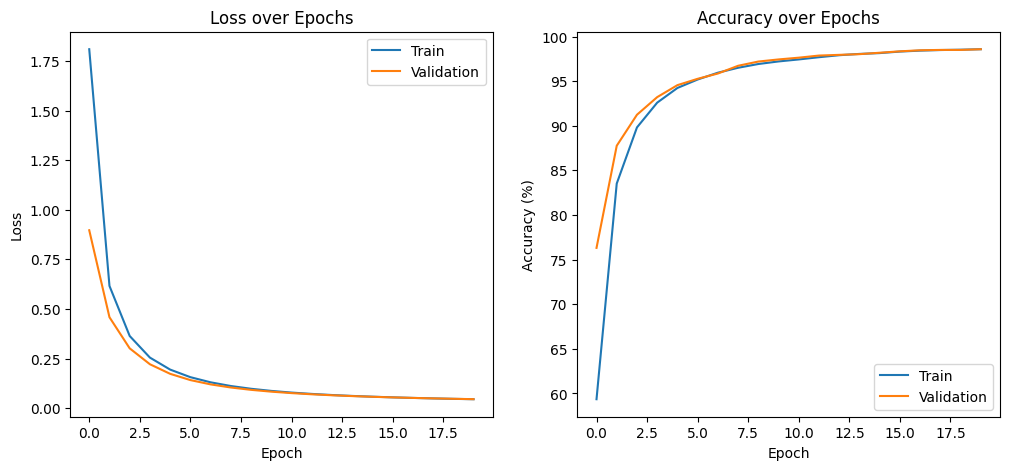

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accuracies, label='Train')
plt.plot(val_accuracies, label='Validation')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.show()


### Final Model Evaluation on Test Set

After training, the model is evaluated on the **unseen test dataset** to measure its final performance.  
We compute:
- **Test Loss** — how well the model fits the test data.  
- **Test Accuracy** — percentage of correctly classified samples (digits 0 and 1).  
This gives an unbiased estimate of how well the model generalizes beyond training and validation data.

In [34]:

total_test_loss, correct_test, total_test = 0, 0, 0
true_labels = []
pred_labels = []

with torch.no_grad():
    for X_test, y_test in test_loader_bin:
        y_true = y_test.float().view(-1, 1)
        y_pred = model(X_test)
        loss = binary_cross_entropy(y_pred, y_true)

        predictions = (y_pred > 0.5).float()
        correct_test += (predictions == y_true).sum().item()
        total_test += y_true.size(0)
        total_test_loss += loss.item() * y_true.size(0)

        # Collect labels for confusion matrix
        true_labels.extend(y_true.squeeze().tolist())
        pred_labels.extend(predictions.squeeze().tolist())

test_loss = total_test_loss / total_test
test_acc = 100 * correct_test / total_test

print("\n=== Final Test Evaluation ===")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")



=== Final Test Evaluation ===
Test Loss: 0.0395
Test Accuracy: 98.70%


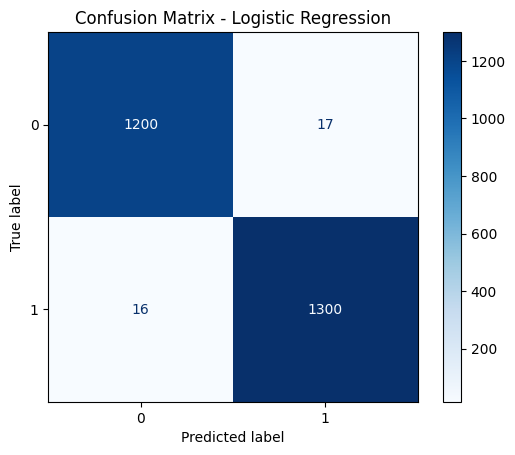

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Confusion matrix
cm = confusion_matrix(true_labels, pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


### Accuracy Visualization

This plot shows how the **training** and **validation accuracy** evolved over the epochs, helping visualize model learning progress.  
A dashed red line marks the **final test accuracy**, allowing an easy comparison between training, validation, and test performance to check for overfitting or underfitting.

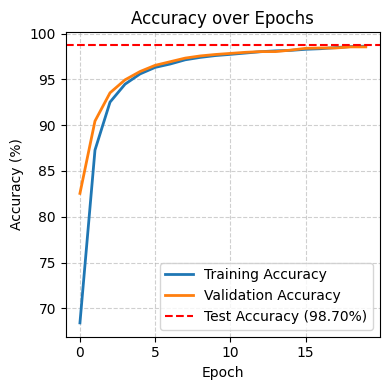

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 4))  # smaller square (4x4 inches)

plt.plot(train_accuracies, label='Training Accuracy', linewidth=2)
plt.plot(val_accuracies, label='Validation Accuracy', linewidth=2)
plt.axhline(y=test_acc, color='r', linestyle='--', label=f'Test Accuracy ({test_acc:.2f}%)')

plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


# Dataset Copy & Split

- Make a deep copy of the MNIST dataset to preserve the original.
- Split the copy into **60% train**, **20% validation**, and **20% test**.
- Inspect one sample to check **feature dimension** and **example label**.


In [11]:
import copy

full_dataset_copy = copy.deepcopy(full_dataset)

train_size = int(0.6 * len(full_dataset_copy))
val_size   = int(0.2 * len(full_dataset_copy))
test_size  = len(full_dataset_copy) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset_copy, [train_size, val_size, test_size], generator=torch.Generator().manual_seed(42)
)

# Inspect one sample
x_sample, y_sample = full_dataset_copy[0]
feature_dim = x_sample.numel()

print("Dataset Summary\n")
print(f"Total samples:        {len(full_dataset_copy)}")
print(f"Training samples:     {len(train_dataset)}")
print(f"Validation samples:   {len(val_dataset)}")
print(f"Test samples:         {len(test_dataset)}")
print(f"Feature dimension:    {feature_dim}")
print(f"Sample tensor shape:  {tuple(x_sample.shape)}")
print(f"Example label:        {y_sample}")


Dataset Summary

Total samples:        60000
Training samples:     36000
Validation samples:   12000
Test samples:         12000
Feature dimension:    784
Sample tensor shape:  (784,)
Example label:        5


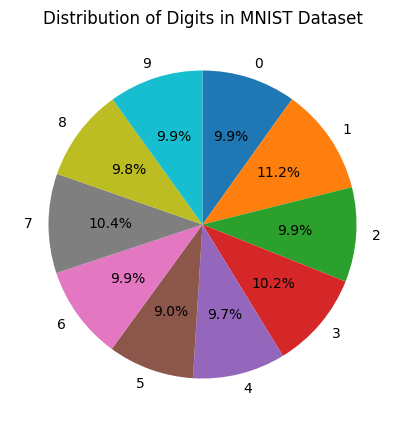

In [12]:
# Get all labels
labels = [label for _, label in full_dataset_copy]

# Count how many times each label appears
unique_labels, counts = torch.unique(torch.tensor(labels), return_counts=True)

# Plotting
plt.figure(figsize=(5, 5))
plt.pie(counts, labels=unique_labels.tolist(), autopct='%1.1f%%', startangle=90, counterclock=False)
plt.title("Distribution of Digits in MNIST Dataset")
plt.show()

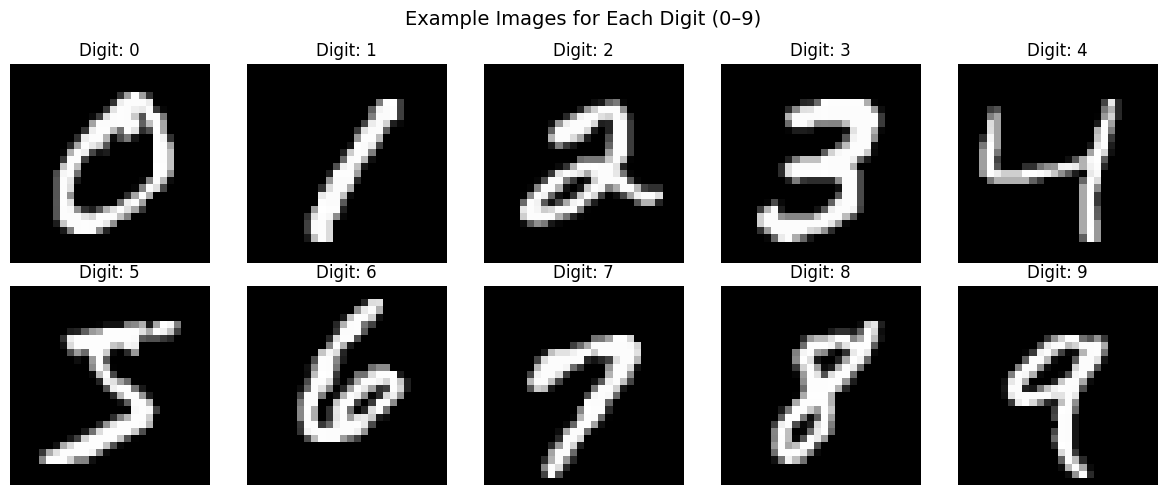

In [13]:
# Store one example image for each digit
examples = {}
for img, label in full_dataset_copy:
    if label not in examples:
        examples[label] = img
    if len(examples) == 10:
        break

# Plotting
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(examples[i].view(28, 28), cmap='gray')  # reshape to 28*28 image
    plt.title(f"Digit: {i}")
    plt.axis('off')

plt.suptitle("Example Images for Each Digit (0–9)", fontsize=14)
plt.tight_layout()
plt.show()

In [37]:

# Create DataLoaders for full 10-class (Softmax) classification
train_loader_full = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader_full   = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader_full  = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Convert loaders to full tensors for direct use in analysis
X_train_t = torch.cat([X for X, _ in train_loader_bin])
Y_train_t = torch.cat([y for _, y in train_loader_bin])

X_val_t = torch.cat([X for X, _ in val_loader_bin])
Y_val_t = torch.cat([y for _, y in val_loader_bin])

print("DataLoaders for Full Dataset (Softmax Regression)\n")
print("Batch size: 64")
print(f"No. of training batches:   {len(train_loader_full)}")
print(f"No. of validation batches: {len(val_loader_full)}")
print(f"No. of test batches:       {len(test_loader_full)}")


DataLoaders for Full Dataset (Softmax Regression)

Batch size: 64
No. of training batches:   563
No. of validation batches: 188
No. of test batches:       188


# Manual Softmax Model

- **Input:** `28x28 = 784` features  
- **Output:** 10 classes  
- **Weights & Bias:** `W` and `b` initialized manually with gradients enabled  
- **Softmax:** Converts logits to probabilities with numerical stability  
- **Cross-Entropy Loss:** Computes mean negative log-likelihood of true class


In [15]:
input_dim = 28 * 28
num_classes = 10

# Initialize weights and bias manually
W = torch.randn(input_dim, num_classes, requires_grad=True)
b = torch.zeros(num_classes, requires_grad=True)

# Softmax function
def softmax(logits):
    norm_logits = logits - logits.max(dim=1, keepdim=True).values
    exp_logits = torch.exp(norm_logits)
    return exp_logits / exp_logits.sum(dim=1, keepdim=True)

# Cross entropy loss
def cross_entropy(y_pred, y_true):
    n = y_true.shape[0]
    log_of_probs = -torch.log(y_pred[range(n), y_true])
    return log_of_probs.mean()


# Manual Softmax Training

- **LR:** 0.01, **Epochs:** 20  
- Forward: `X @ W + b` → softmax → cross-entropy  
- Backward: update `W`, `b`  
- Track train & validation loss/accuracy


In [16]:
learning_rate = 0.01
epochs = 20
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(epochs):
    total_train_loss, correct_train, total_train = 0, 0, 0
    for X_batch, y_batch in train_loader_full:
        logits = X_batch @ W + b
        y_pred = softmax(logits)
        loss = cross_entropy(y_pred, y_batch)

        # Gradient Descent
        loss.backward()
        with torch.no_grad():
            W -= learning_rate * W.grad
            b -= learning_rate * b.grad
        W.grad.zero_()
        b.grad.zero_()

        total_train_loss += loss.item() * y_batch.size(0)
        correct_train += (y_pred.argmax(1) == y_batch).sum().item()
        total_train += y_batch.size(0)

    train_loss = total_train_loss / total_train
    train_acc = 100 * correct_train / total_train

    # --- Validation ---
    total_val_loss, correct_val, total_val = 0, 0, 0
    with torch.no_grad():
        for X_val, y_val in val_loader_full:
            logits = X_val @ W + b
            y_pred = softmax(logits)
            loss = cross_entropy(y_pred, y_val)
            total_val_loss += loss.item() * y_val.size(0)
            correct_val += (y_pred.argmax(1) == y_val).sum().item()
            total_val += y_val.size(0)

    val_loss = total_val_loss / total_val
    val_acc = 100 * correct_val / total_val

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")


Epoch 1/20 | Train Loss: 8.1154, Train Acc: 18.37% | Val Loss: 5.5935, Val Acc: 27.23%
Epoch 2/20 | Train Loss: 4.3941, Train Acc: 36.88% | Val Loss: 3.6234, Val Acc: 44.62%
Epoch 3/20 | Train Loss: 3.1005, Train Acc: 49.94% | Val Loss: 2.7546, Val Acc: 54.26%
Epoch 4/20 | Train Loss: 2.4673, Train Acc: 57.79% | Val Loss: 2.2776, Val Acc: 60.62%
Epoch 5/20 | Train Loss: 2.0935, Train Acc: 62.71% | Val Loss: 1.9770, Val Acc: 64.64%
Epoch 6/20 | Train Loss: 1.8471, Train Acc: 66.27% | Val Loss: 1.7682, Val Acc: 67.52%
Epoch 7/20 | Train Loss: 1.6709, Train Acc: 68.86% | Val Loss: 1.6149, Val Acc: 69.92%
Epoch 8/20 | Train Loss: 1.5373, Train Acc: 70.96% | Val Loss: 1.4964, Val Acc: 71.97%
Epoch 9/20 | Train Loss: 1.4329, Train Acc: 72.58% | Val Loss: 1.4027, Val Acc: 73.50%
Epoch 10/20 | Train Loss: 1.3482, Train Acc: 73.94% | Val Loss: 1.3258, Val Acc: 74.86%
Epoch 11/20 | Train Loss: 1.2781, Train Acc: 75.03% | Val Loss: 1.2620, Val Acc: 75.93%
Epoch 12/20 | Train Loss: 1.2188, Train A

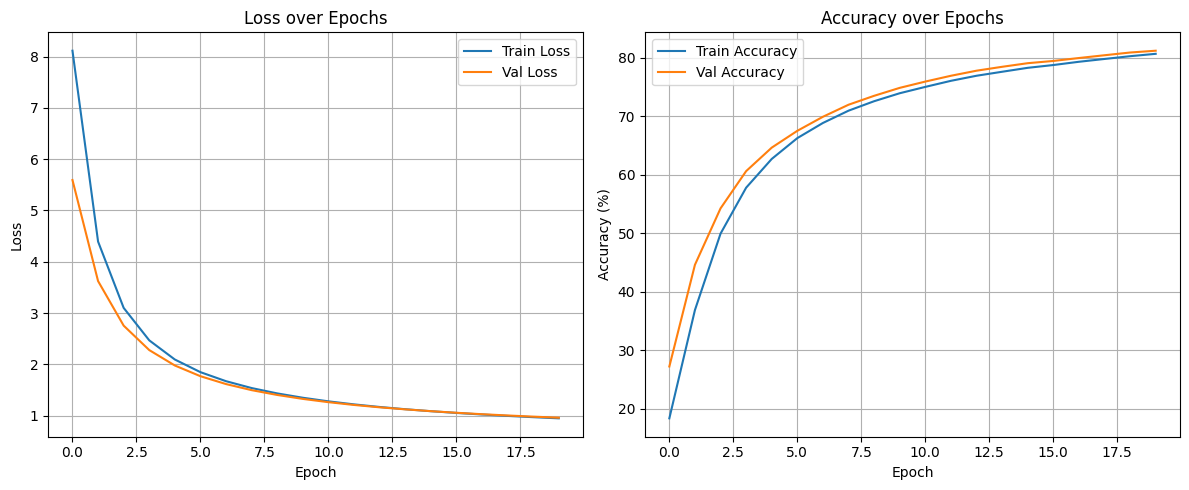

In [17]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# Manual Softmax Test Evaluation

- Evaluate on `test_loader_full` using trained `W` and `b`  
- Compute softmax → cross-entropy → predicted labels  
- Track test loss and accuracy  

**Results:**  
- `Test Loss = {test_loss:.4f}`  
- `Test Accuracy = {test_acc:.2f}%`


In [18]:

model_predictions, true_labels = [], []
total_test_loss, correct_test, total_test = 0, 0, 0

with torch.no_grad():
    for X_test, y_test in test_loader_full:
        logits = X_test @ W + b
        y_pred = softmax(logits)
        loss = cross_entropy(y_pred, y_test)

        preds = y_pred.argmax(1)
        total_test_loss += loss.item() * y_test.size(0)
        correct_test += (preds == y_test).sum().item()
        total_test += y_test.size(0)

        model_predictions.extend(preds.tolist())
        true_labels.extend(y_test.tolist())

test_loss = total_test_loss / total_test
test_acc = 100 * correct_test / total_test

print(f"\n=== Test Results ===")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")



=== Test Results ===
Test Loss: 1.0041
Test Accuracy: 79.88%


# Confusion Matrix

- Compute using `sklearn.metrics.confusion_matrix` with true vs predicted labels  
- Display using `ConfusionMatrixDisplay`  
- Visualizes which digits are being classified correctly or misclassified


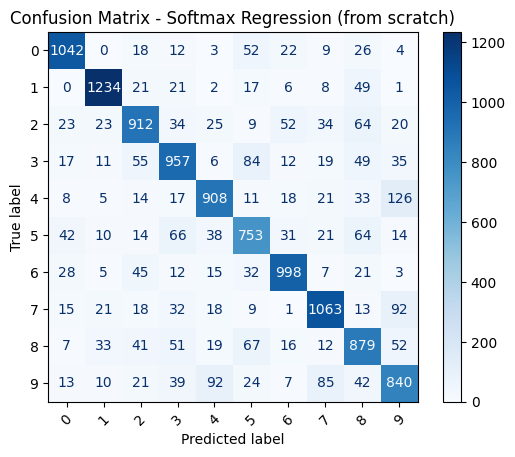

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute confusion matrix
cm = confusion_matrix(true_labels, model_predictions)

# Display it nicely
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix - Softmax Regression (from scratch)")
plt.show()


# Per-Class Accuracy

- Diagonal of confusion matrix ÷ total per class × 100  
- Shows accuracy for each digit


In [25]:
import numpy as np

# Convert to NumPy array if it's not already
cm_np = np.array(cm)

per_class_accuracy = cm_np.diagonal() / cm_np.sum(axis=1) * 100

for i, acc in enumerate(per_class_accuracy):
    print(f"Class {i}: {acc:.2f}% accuracy")


Class 0: 87.71% accuracy
Class 1: 90.80% accuracy
Class 2: 76.25% accuracy
Class 3: 76.87% accuracy
Class 4: 78.21% accuracy
Class 5: 71.51% accuracy
Class 6: 85.59% accuracy
Class 7: 82.92% accuracy
Class 8: 74.68% accuracy
Class 9: 71.61% accuracy


# Built-in Softmax Model (PyTorch)

- **Model:** Single linear layer mapping 784 → 10 (logits)  
- **Loss:** `nn.CrossEntropyLoss` (applies softmax internally)  
- **Optimizer:** SGD with learning rate 0.01


In [19]:
import torch
import torch.nn as nn

input_dim = 28 * 28
num_classes = 10

# Simple linear (softmax) model
class SoftmaxModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(input_dim, num_classes)

    def forward(self, X):
        logits = self.linear(X)
        return logits

model = SoftmaxModel()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)



# Training the Built-in Softmax Model

- **Dataset:** Deep copy of `full_dataset`  
- **Split:** 60% train, 20% val, 20% test  
- **DataLoaders:** Batch size 64  
- **Training:** 20 epochs  
- **Metrics stored:** `train_losses_built_in`, `val_losses_built_in`, `train_accuracies_built_in`, `val_accuracies_built_in`  
- **Notes:** Uses `nn.CrossEntropyLoss` and `SGD` optimizer


In [20]:
full_dataset_copy2 = copy.deepcopy(full_dataset)

train_size = int(0.6 * len(full_dataset_copy2))
val_size   = int(0.2 * len(full_dataset_copy2))
test_size  = len(full_dataset_copy2) - train_size - val_size

train_dataset_builtin, val_dataset_builtin, test_dataset_builtin = random_split(
    full_dataset_copy2, [train_size, val_size, test_size], generator=torch.Generator().manual_seed(42)
)

train_loader_builtin = DataLoader(train_dataset_builtin, batch_size=64, shuffle=True)
val_loader_builtin   = DataLoader(val_dataset_builtin, batch_size=64, shuffle=False)
test_loader_builtin  = DataLoader(test_dataset_builtin, batch_size=64, shuffle=False)

epochs = 20
train_losses_built_in, val_losses_built_in = [], []
train_accuracies_built_in, val_accuracies_built_in = [], []

for epoch in range(epochs):
    total_train_loss, correct_train, total_train = 0, 0, 0

    for X_batch, y_batch in train_loader_builtin:
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item() * y_batch.size(0)
        correct_train += (logits.argmax(1) == y_batch).sum().item()
        total_train += y_batch.size(0)

    train_loss = total_train_loss / total_train
    train_acc = 100 * correct_train / total_train

    # Validation
    model.eval()
    total_val_loss, correct_val, total_val = 0, 0, 0
    with torch.no_grad():
        for X_val, y_val in val_loader_builtin:
            logits = model(X_val)
            loss = criterion(logits, y_val)

            total_val_loss += loss.item() * y_val.size(0)
            correct_val += (logits.argmax(1) == y_val).sum().item()
            total_val += y_val.size(0)

    val_loss = total_val_loss / total_val
    val_acc = 100 * correct_val / total_val

    train_losses_built_in.append(train_loss)
    val_losses_built_in.append(val_loss)
    train_accuracies_built_in.append(train_acc)
    val_accuracies_built_in.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")


Epoch 1/20 | Train Loss: 1.1814, Train Acc: 76.96% | Val Loss: 0.7615, Val Acc: 84.41%
Epoch 2/20 | Train Loss: 0.6561, Train Acc: 85.48% | Val Loss: 0.5858, Val Acc: 86.47%
Epoch 3/20 | Train Loss: 0.5441, Train Acc: 86.91% | Val Loss: 0.5154, Val Acc: 87.15%
Epoch 4/20 | Train Loss: 0.4902, Train Acc: 87.62% | Val Loss: 0.4758, Val Acc: 87.98%
Epoch 5/20 | Train Loss: 0.4572, Train Acc: 88.18% | Val Loss: 0.4499, Val Acc: 88.37%
Epoch 6/20 | Train Loss: 0.4343, Train Acc: 88.64% | Val Loss: 0.4308, Val Acc: 88.85%
Epoch 7/20 | Train Loss: 0.4172, Train Acc: 88.92% | Val Loss: 0.4166, Val Acc: 88.93%
Epoch 8/20 | Train Loss: 0.4039, Train Acc: 89.18% | Val Loss: 0.4053, Val Acc: 89.14%
Epoch 9/20 | Train Loss: 0.3930, Train Acc: 89.35% | Val Loss: 0.3959, Val Acc: 89.42%
Epoch 10/20 | Train Loss: 0.3840, Train Acc: 89.54% | Val Loss: 0.3885, Val Acc: 89.61%
Epoch 11/20 | Train Loss: 0.3764, Train Acc: 89.75% | Val Loss: 0.3815, Val Acc: 89.78%
Epoch 12/20 | Train Loss: 0.3696, Train A

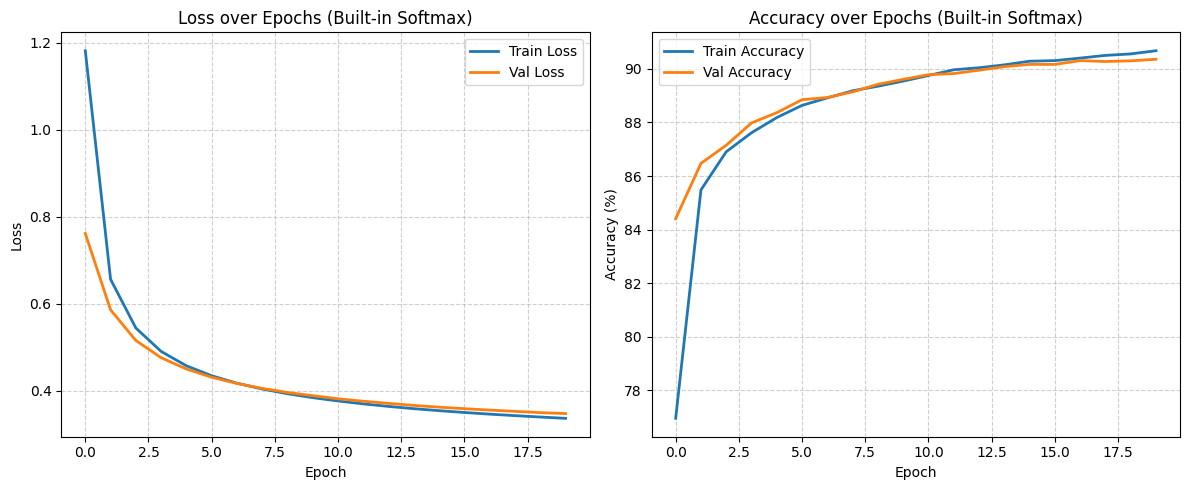

In [21]:

plt.figure(figsize=(12, 5))

# Plot loss curves
plt.subplot(1, 2, 1)
plt.plot(train_losses_built_in, label='Train Loss', linewidth=2)
plt.plot(val_losses_built_in, label='Val Loss', linewidth=2)
plt.title('Loss over Epochs (Built-in Softmax)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Plot accuracy curves
plt.subplot(1, 2, 2)
plt.plot(train_accuracies_built_in, label='Train Accuracy', linewidth=2)
plt.plot(val_accuracies_built_in, label='Val Accuracy', linewidth=2)
plt.title('Accuracy over Epochs (Built-in Softmax)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


# Built-in Softmax Model - Test Evaluation

- **Test Loss:** Calculated as the average cross-entropy over the test set  
- **Test Accuracy:** Percentage of correct predictions  
- **Implementation:** Uses `torch.no_grad()` to disable gradient tracking during evaluation  
- **Metrics:** `test_loss`, `test_acc`


In [22]:

correct_test, total_test, total_test_loss = 0, 0, 0

with torch.no_grad():
    for X_test, y_test in test_loader_builtin:
        logits = model(X_test)
        loss = criterion(logits, y_test)
        total_test_loss += loss.item() * y_test.size(0)
        correct_test += (logits.argmax(1) == y_test).sum().item()
        total_test += y_test.size(0)

test_loss = total_test_loss / total_test
test_acc = 100 * correct_test / total_test

print(f"\nTest Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.2f}%")



Test Loss: 0.3570, Test Accuracy: 90.14%


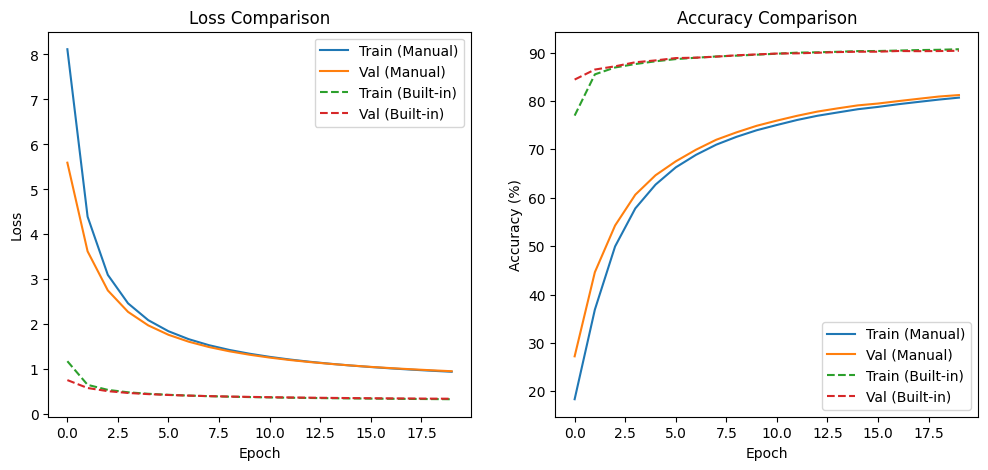

In [23]:

plt.figure(figsize=(12,5))

# Loss comparison
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train (Manual)')
plt.plot(val_losses, label='Val (Manual)')
plt.plot(train_losses_built_in, label='Train (Built-in)', linestyle='--')
plt.plot(val_losses_built_in, label='Val (Built-in)', linestyle='--')
plt.title('Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy comparison
plt.subplot(1,2,2)
plt.plot(train_accuracies, label='Train (Manual)')
plt.plot(val_accuracies, label='Val (Manual)')
plt.plot(train_accuracies_built_in, label='Train (Built-in)', linestyle='--')
plt.plot(val_accuracies_built_in, label='Val (Built-in)', linestyle='--')
plt.title('Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.show()


In [38]:
import torch
import numpy as np

def train_logistic_regression(model, train_loader, val_loader, learning_rate=0.01, epochs=20):
    W, b = model
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    binary_cross_entropy = torch.nn.BCELoss()

    for epoch in range(epochs):
        total_train_loss, correct_train, total_train = 0, 0, 0

        for X_batch, y_batch in train_loader:
            y_true = y_batch.float().view(-1, 1)
            y_pred = torch.sigmoid(X_batch @ W + b)
            loss = binary_cross_entropy(y_pred, y_true)

            loss.backward()
            with torch.no_grad():
                W -= learning_rate * W.grad
                b -= learning_rate * b.grad
            W.grad.zero_()
            b.grad.zero_()

            predictions = (y_pred > 0.5).float()
            correct_train += (predictions == y_true).sum().item()
            total_train += y_true.size(0)
            total_train_loss += loss.item() * y_true.size(0)

        train_loss = total_train_loss / total_train
        train_acc = 100 * correct_train / total_train

        # Validation
        total_val_loss, correct_val, total_val = 0, 0, 0
        with torch.no_grad():
            for X_val, y_val in val_loader:
                y_true = y_val.float().view(-1, 1)
                y_pred = torch.sigmoid(X_val @ W + b)
                loss = binary_cross_entropy(y_pred, y_true)

                predictions = (y_pred > 0.5).float()
                correct_val += (predictions == y_true).sum().item()
                total_val += y_true.size(0)
                total_val_loss += loss.item() * y_true.size(0)

        val_loss = total_val_loss / total_val
        val_acc = 100 * correct_val / total_val

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

    return train_losses, val_losses, train_accs, val_accs


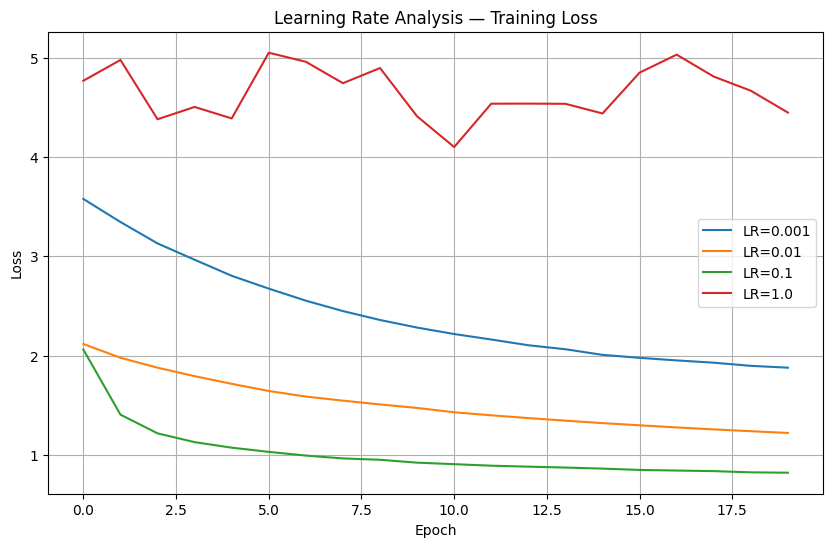

In [40]:
from torch.utils.data import DataLoader, TensorDataset

learning_rates = [0.001, 0.01, 0.1, 1.0]
epochs = 20

plt.figure(figsize=(10, 6))
for lr in learning_rates:
    # Reinitialize parameters for each run
    W = torch.randn(X_train_t.shape[1], 1, requires_grad=True)
    b = torch.zeros(1, requires_grad=True)
    model = (W, b)

    train_loader_lr = DataLoader(TensorDataset(X_train_t, Y_train_t), batch_size=64, shuffle=True)
    val_loader_lr = DataLoader(TensorDataset(X_val_t, Y_val_t), batch_size=64, shuffle=False)

    train_losses, val_losses, _, _ = train_logistic_regression(model, train_loader_lr, val_loader_lr, learning_rate=lr, epochs=epochs)
    plt.plot(train_losses, label=f"LR={lr}")

plt.title("Learning Rate Analysis — Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


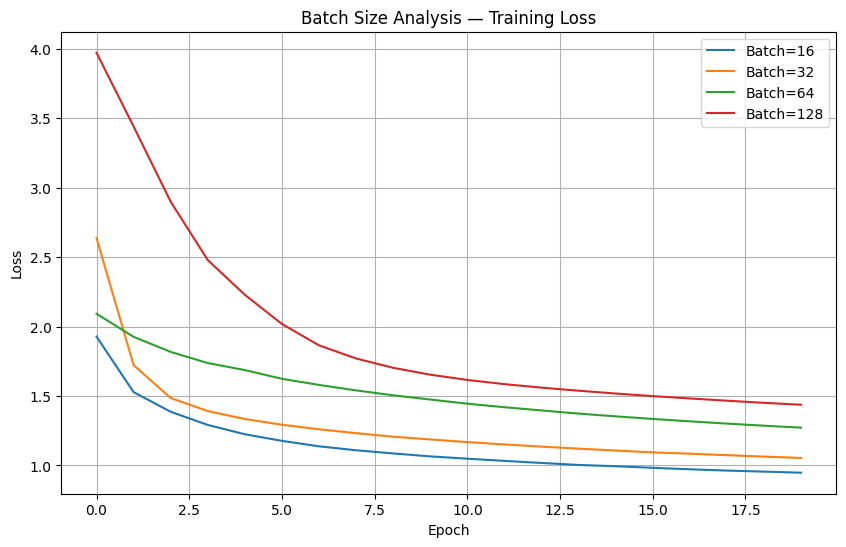

In [42]:
batch_sizes = [16, 32, 64, 128]
epochs = 20
lr = 0.01  # use the best LR from above

plt.figure(figsize=(10, 6))
for bs in batch_sizes:
    W = torch.randn(X_train_t.shape[1], 1, requires_grad=True)
    b = torch.zeros(1, requires_grad=True)
    model = (W, b)

    train_loader_bs = DataLoader(TensorDataset(X_train_t, Y_train_t), batch_size=bs, shuffle=True)
    val_loader_bs = DataLoader(TensorDataset(X_val_t, Y_val_t), batch_size=bs, shuffle=False)

    train_losses, val_losses, _, _ = train_logistic_regression(model, train_loader_bs, val_loader_bs,
                                                               learning_rate=lr, epochs=epochs)
    plt.plot(train_losses, label=f"Batch={bs}")

plt.title("Batch Size Analysis — Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()
